# GB84 Model Testing Using in-situ measurements from Cabauw, NL

A notebook to perform test runs with the python implementation of the Georgakakos and Bras model from *"A Hydrologically Useful Station Precipitation Model"* (1984)

This Jupyter Notebook tests a precipitation model using validated data from the CESAR network as inputs, with a 10min resolution.

The input data used in this model consist of a combined dataset derived from the **Cesar Network surface data** and **Cloudnet MWR profiles** corresponding to Cabauw.
#### Required Inputs

- **Surface Inputs** (from ERA5 Single Levels):
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature



In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84 import calculations_for_convection, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
from scipy import signal
from scipy.stats import pearsonr

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)
4. [Result Analysis](#Result-Analysis)


## Loading the Data


After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.


In [2]:
#choose time period of runs
slice_str = "2024-07-01 00:00:00, 2024-07-03 23:59:00"
slice_tuple = tuple(slice_str.split(", "))

#### CESAR surface measurements 

In [3]:
ground_measurements = xr.open_mfdataset(r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')
var = ['TA002','P0','TD002','RH002']
measurements = ground_measurements[var]
measurements = measurements.dropna(dim='time',how='any')

measurements_used = measurements.sel(time=slice(*slice_tuple))

In [4]:
time = measurements_used.sel(time=slice(*slice_tuple)).time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Radiometer LWP 

The liquid water path as measured from the MWR in Cabauw, to be used as the initial state

In [5]:
radiometer = xr.open_mfdataset(r'..\data\Cabaw_radiometer\*.nc')
radiometer_lwp = radiometer['lwp'].sel(time=time,method='nearest')

Storing the time values and the timestep.

In [6]:
#inputs

#temperature on the ground
T_surf = measurements_used['TA002'].values #[K]


#pressure
p_surf = measurements_used['P0'].values*100  #[Pa]

#dew point temperature
T_d_arr = measurements_used['TD002'].values     #[K]

#state
X = np.zeros(len(T_surf))
X[0] = radiometer_lwp[0]   #initial state in kg/m2 taken from radiometer LWP

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [7]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=time,method='nearest')
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


### Testing the model

#### Initializing Model Output Arrays

Empty arrays are created to store the outputs of the model. These arrays are initialized with dimensions `(time)`.


In [8]:
P = np.zeros(len(T_surf))
P_0 = np.zeros(len(T_surf))
f_arr = np.zeros(len(T_surf))
h_arr = np.zeros(len(T_surf))

#### Model running loop

Loop for the thermodynamical calculations at each timestep and then for the calculation of precipitation rates and state propagation in time

In [9]:
#loop for finding the precipitation given the T_0 and p

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #thermodynamics and in cloud calculations
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = calculations_for_convection(T_0, T_d, p_0, obs=False).run()
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)

    #fluxes
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water

    #precipitation
    P[i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()*X[i]

    #state update
    if i<(len(T_surf)-1):
        X[i+1] = X[i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X[i])


### Plots and results

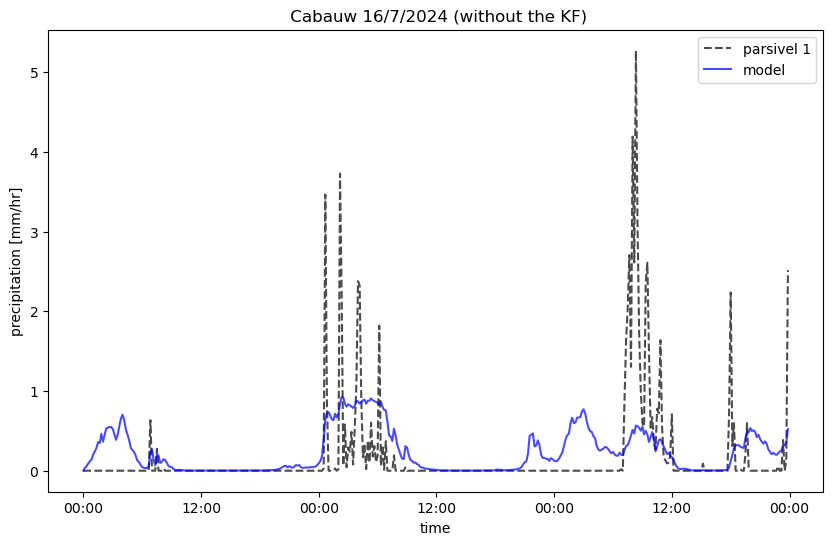

In [10]:
plt.figure(figsize=(10,6))
t_step = np.linspace(0,len(P),len(P))
import matplotlib.dates as mdates

#plt.plot(t_step,P_0*3600,label='model (steady state)')
plt.plot(time,rain_rate,label='parsivel 1',color='black',alpha=0.7,linestyle='--') 
plt.plot(time,P*3600,label='model',color='blue',alpha=0.7)   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xlabel('time')
plt.title(' Cabauw 16/7/2024 (without the KF)')
plt.ylabel('precipitation [mm/hr]')
plt.legend()
#plt.grid()
plt.show()


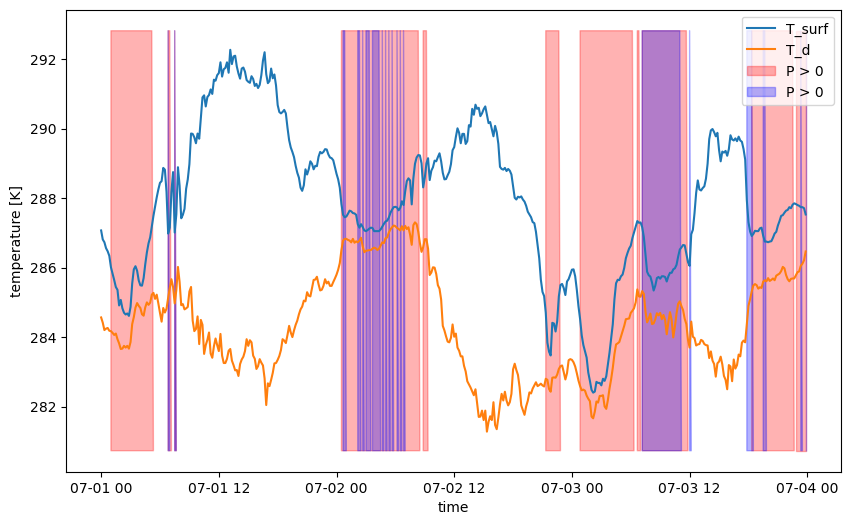

In [42]:
time_mask = np.where(P*3600 > 0.2)
time_actual = rain_rate.time[np.where(rain_rate > 0.2)]
plt.figure(figsize=(10,6))
plt.plot(time, T_surf, label='T_surf')
plt.plot(time, T_d_arr, label='T_d')

# Get y-axis limits after plotting
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P*3600 > 0.2).values if hasattr(P*3600, 'values') else (P*3600 > 0.2)  # Handle xarray
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.fill_between(time, y_min, y_max, where=mask_actual, 
                 alpha=0.3, color='blue', label='P > 0', interpolate=True)
plt.xlabel('time')
plt.ylabel('temperature [K]')
plt.legend()

In [50]:
np.mean((T_s-T_d_arr)[time_mask])

1.1404521

In [52]:
np.mean((p_s-p_surf)[time_mask])

-2416.802

In [53]:
np.mean((p_s-p_surf))

-2556.549

In [45]:
np.mean(T_d_arr)

284.31516

In [46]:
np.mean(T_d_arr[time_mask])

285.02408

In [49]:
print(np.mean(T_surf), np.mean(T_surf[time_mask]))

287.91937 286.2688


In [48]:
time_mask

(array([  6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,  17,  18,
         19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,
         41,  42,  45, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
        157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
        170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182,
        183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 197,
        198, 199, 272, 273, 274, 275, 276, 277, 278, 279, 280, 293, 294,
        295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307,
        308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320,
        321, 322, 323, 324, 325, 328, 329, 331, 332, 333, 334, 335, 336,
        337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349,
        350, 351, 352, 353, 354, 355, 356, 357, 358, 398, 399, 400, 401,
        402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414,
        415, 416, 417, 418, 419, 420, 421, 422, 423

Text(0, 0.5, 'average hourly precipitation (mm/hr)')

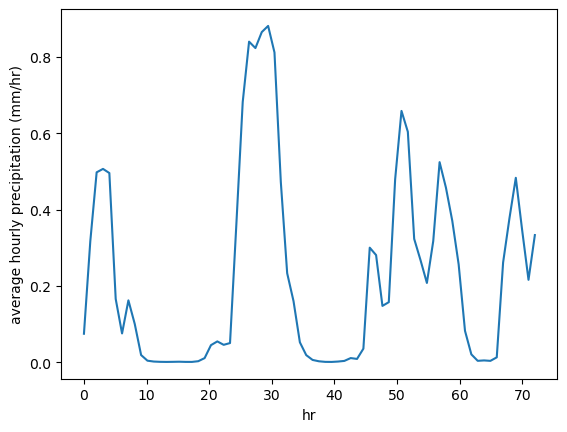

In [12]:
Pmeas = rain_rate.sel(time=slice('2024-07-05 00:00:00', '2024-07-07 23:59:00'))
averages_P = [np.mean(P[i:i+6]) for i in range(0, len(P), 6)]
averages_Pmeas=[np.mean(Pmeas[i:i+6]) for i in range(0, len(P), 6)]
t_hr = np.linspace(0,len(averages_P),len(averages_P))

plt.plot(t_hr,np.array(averages_P)*3600,label='model (Kf)')   #P [kg/m2/s] = P/1000kg/m3 = P/1000 m/s = P* 3600 [mm/hr]
plt.plot(t_hr,averages_Pmeas,label='observation')
plt.xlabel('hr')
plt.ylabel('average hourly precipitation (mm/hr)')

## Result analysis

In [13]:
count_prec = np.sum((rain_rate>0.38) & (P*3600 > 0.25))
count_no_prec = np.sum((rain_rate==0) & (P*3600<0.25))
count_model_dubious = np.sum(
    (rain_rate> 0) & (rain_rate <= 0.38) & (P * 3600 < 0.38)) #& (P * 3600 > 0.25)) \
  #+ np.sum((rain_rate == 0) & (P * 3600 < 0.38) )
count_wrong_prec = np.sum((rain_rate==0) & (P*3600 > 0.25)) + np.sum((rain_rate > 0) & (rain_rate <= 0.38) & (P*3600 > 0.38))
count_wrong_zero = np.sum((rain_rate>0.38) & (P*3600 < 0.25))

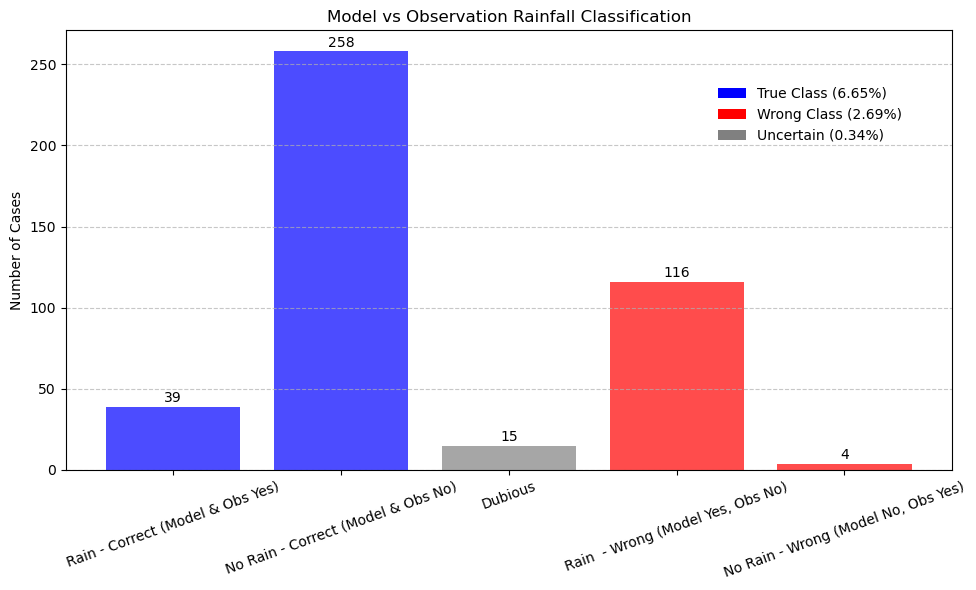

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# Define labels and values
labels = [
    'Rain - Correct (Model & Obs Yes)',
    'No Rain - Correct (Model & Obs No)',
    'Dubious',
    'Rain  - Wrong (Model Yes, Obs No)',
    'No Rain - Wrong (Model No, Obs Yes)'
]

values = [
    count_prec,
    count_no_prec,
    count_model_dubious,
    
    count_wrong_prec,
    count_wrong_zero
]

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['blue', 'blue', 'gray','red', 'red'],alpha=0.7)

# Add count labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')

legend_elements = [
    Patch(facecolor='blue', label=f'True Class ({(count_prec+count_no_prec)/4464*100:.2f}%)'),
    #Patch(facecolor='blue', label='Correct No Rain'),
    #Patch(facecolor='orange', label='Dubious Cases'),
    Patch(facecolor='red', label=f'Wrong Class ({(count_wrong_prec+count_wrong_zero)/4464*100:.2f}%)'),#label='Correct No Rain'),
    Patch(facecolor='grey', label=f'Uncertain ({(count_model_dubious)/4464*100:.2f}%)')
]

# Add the custom legend at the top
plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.84, 0.9),
           ncol=1, frameon=False)
# Formatting
plt.title("Model vs Observation Rainfall Classification")
plt.ylabel("Number of Cases")
plt.xticks(rotation=20)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


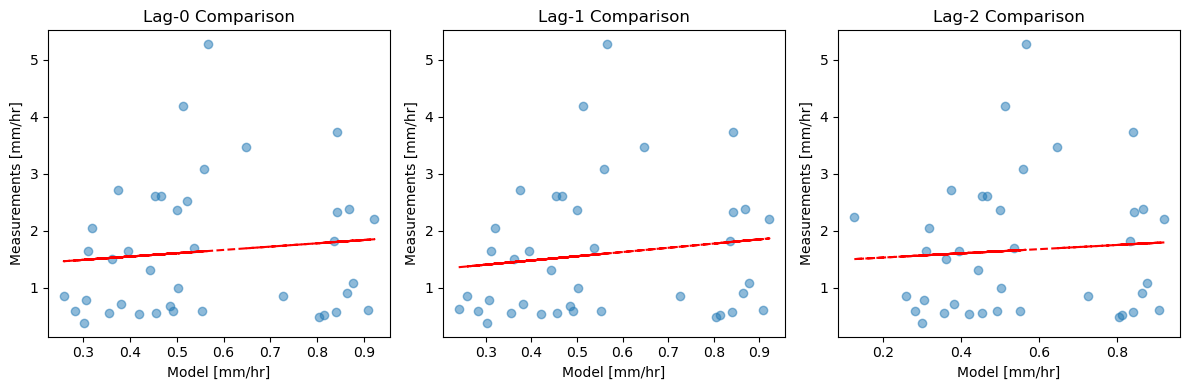

In [15]:
import matplotlib.pyplot as plt

# Prepare indices
indices     = np.where((rain_rate > 0.38) & (P * 3600 > 0.25))
indices_1   = np.where((rain_rate[0:-1] > 0.38) & (P[1:] * 3600 > 0.25))
indices_2   = np.where((rain_rate[0:-2] > 0.38) & (P[2:] * 3600 > 0.25))

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

# Panel 1: Lag 0
z_0 = np.polyfit(P[indices] * 3600, rain_rate[indices], 1)
p_0 = np.poly1d(z_0)
axes[0].scatter(P[indices] * 3600, rain_rate[indices], alpha=0.5)
axes[0].plot(P[indices] * 3600, p_0(P[indices] * 3600), "r--")
axes[0].set_title('Lag-0 Comparison')
axes[0].set_xlabel('Model [mm/hr]')
axes[0].set_ylabel('Measurements [mm/hr]')

# Panel 2: Lag -1 (measurement leads model by 1)
z_1 = np.polyfit(P[indices_1] * 3600, rain_rate[indices_1], 1)
p_1 = np.poly1d(z_1)
axes[1].scatter(P[indices_1] * 3600, rain_rate[0:-1][indices_1], alpha=0.5)
axes[1].plot(P[indices_1] * 3600, p_1(P[indices_1] * 3600), "r--")
axes[1].set_title('Lag-1 Comparison')
axes[1].set_xlabel('Model [mm/hr]')
axes[1].set_ylabel('Measurements [mm/hr]')

# Panel 3: Lag +1 (model leads measurement by 1)
z_2 = np.polyfit(P[indices_2] * 3600, rain_rate[indices_2], 1)
p_2 = np.poly1d(z_2)
axes[2].scatter(P[indices_2] * 3600, rain_rate[0:-2][indices_2], alpha=0.5)
axes[2].plot(P[indices_2] * 3600, p_2(P[indices_2] * 3600), "r--")
axes[2].set_title('Lag-2 Comparison')
axes[2].set_xlabel('Model [mm/hr]')
axes[2].set_ylabel('Measurements [mm/hr]')

# Optional: consistent y-axis or limits
# for ax in axes:
#     ax.set_ylim(0, 10)
#     ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

#plt.ylim(0,10)

In [16]:
correlation = signal.correlate(rain_rate, P*3600, mode="full")

lags = signal.correlation_lags(rain_rate.size, P.size, mode="full")

lag = lags[np.argmax(correlation)]

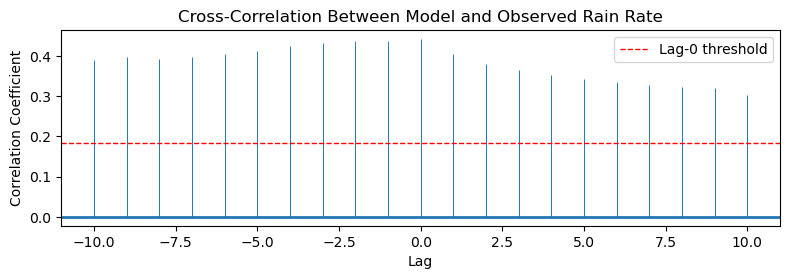

In [17]:
import matplotlib.pyplot as plt

# Create the figure and axis
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(211)

# Cross-correlation
ax1.xcorr(rain_rate, P * 3600, usevlines=True,
          maxlags=10, normed=True,
          lw=2, linewidth=0.7)

# Horizontal reference line
ax1.axhline(y=0.18337568, color='r', linestyle='dashed', linewidth=1, label='Lag-0 threshold')

# Axis labels and title
ax1.set_title('Cross-Correlation Between Model and Observed Rain Rate')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Correlation Coefficient')

# Add legend
ax1.legend(loc='upper right')

# Optional: adjust layout
plt.tight_layout()
plt.show()


Text(0, 0.5, 'liquid water [kg/m^2]')

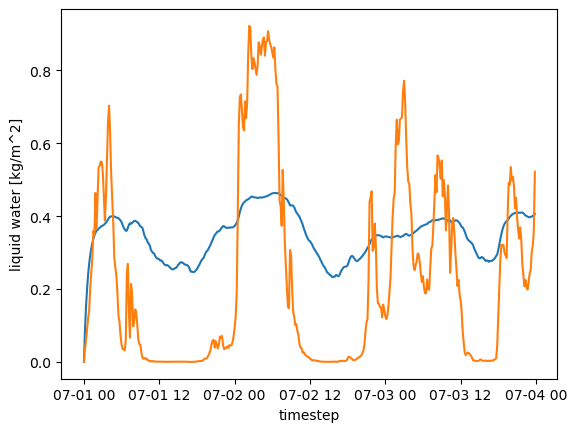

In [59]:
#state evolution

plt.plot(measurements_used.time,X/Z_c*1000)
plt.plot(measurements_used.time,P*3600)
#plt.plot(july.time,july.lwp)
plt.xlabel('timestep')
plt.ylabel('liquid water [kg/m^2]')

In [19]:
v_arr = np.zeros(len(T_surf))
O_b_arr = np.zeros(len(T_surf))
O_h_arr = np.zeros(len(T_surf))
I_arr = np.zeros(len(T_surf))

for i in range(0,len(T_surf)):
    #inputs
    T_0 = T_surf[i]
    p_0 = p_surf[i]
    T_d = T_d_arr[i]

    #meteorological variables
    p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = calculations_for_convection(T_0, T_d, p_0, obs=False).run()
    rho = rho_m(T_s,T_t,p_s,p_t)
    v_updr = v(T_m,T_s_up)
    v_arr[i] = v_updr
    Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
    O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
    print(non_dim_numbers(v_updr)[1])
    O_b_arr[i] = O_b*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    O_h_arr[i] = O_t*X[i]*non_dim_numbers(v_updr)[0]/Z_c
    I_arr[i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
     


0.5723356991995986
0.5718535959097876
0.5701911527598138
0.5711560307308081
0.5716544460962993
0.5713598687893047
0.5724145360354619
0.5725647534315301
0.5726529101071264
0.5737013665432005
0.5724829835527195
0.5728743125959371
0.5708454212490913
0.5717416089017917
0.5729206488828361
0.5726201536998725
0.5729869613904425
0.5724727515596802
0.5733800738362319
0.5758782372591668
0.5763493002930911
0.5785284974616088
0.5801613022499157
0.5803837340544618
0.5803033645752217
0.5786965400272875
0.5775886033264386
0.5784402985126185
0.5785643909724087
0.5770264852779082
0.5769895147532272
0.5780001768176054
0.5774207919078871
0.5749176112721186
0.5751107607841416
0.5719786083072491
0.568784052939057
0.5662961824442312
0.5685601174600137
0.5675462449861761
0.5708949253701049
0.5780066104505415
0.5799915566417216
0.5786547676333976
0.5745911670040643
0.5764704021751623
0.5781299800543627
0.5793285245624951
0.5773349336703675
0.5746155822600336
0.5745535040909251
0.5725534000245142
0.57077270506

In [57]:
from GB84 import w

print(np.mean(w(T_d_arr,p_surf)), np.mean(w(T_d_arr,p_surf)[time_mask]))

0.008812251 0.009188379


Text(0, 0.5, 'updraft velocity [m/s]')

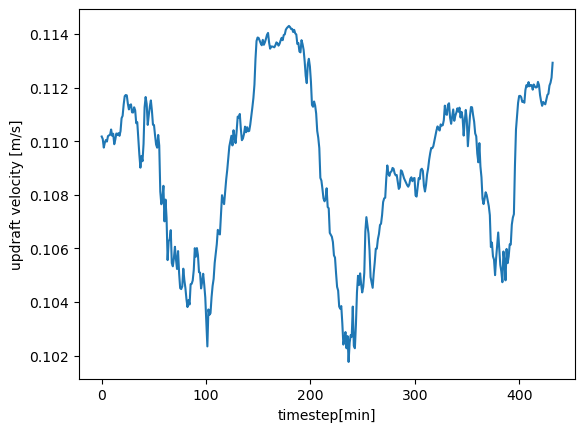

In [20]:
plt.plot(t_step,v_arr)
plt.xlabel('timestep[min]')
plt.ylabel('updraft velocity [m/s]')

Text(0.5, 1.0, 'Cloud Fluxes')

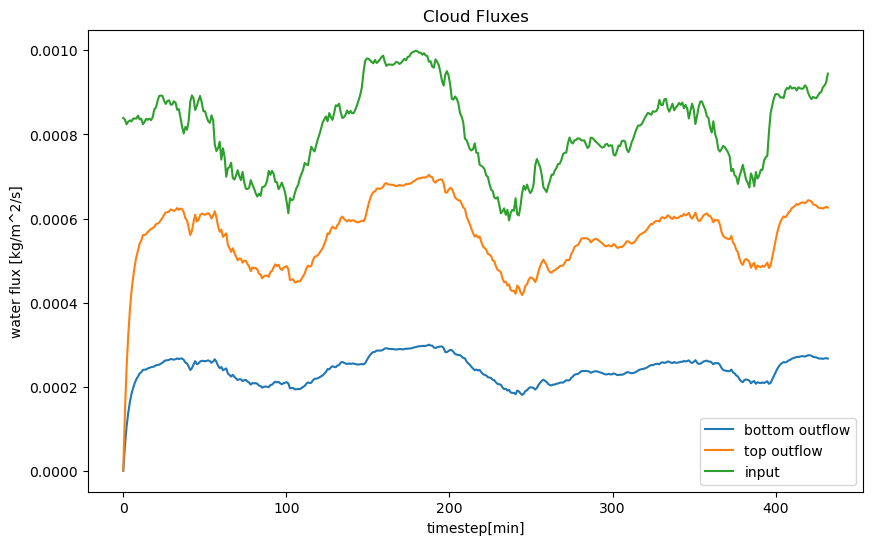

In [21]:
A = np.zeros(30000)
#for i in range(0,3000):
    #if measurements['rain_rate'].values[7000+i]>0:
        #A[i] = t_step[i]
    #else:
        #A[i] = 0
    

plt.figure(figsize=(10,6))
plt.plot(t_step,O_b_arr,label='bottom outflow')
plt.plot(t_step,O_h_arr,label='top outflow')
plt.plot(t_step,I_arr,label='input')
plt.xlabel('timestep[min]')
plt.ylabel('water flux [kg/m^2/s]')
#plt.vlines(A,0,0.005,alpha=0.1,color='red')
plt.legend()
plt.title('Cloud Fluxes')